In [533]:
# ==========================================================
# IMPORTS
# ==========================================================

# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Reproductibilité
import random

# ==========================================================
# CONFIGURATION
# ==========================================================

# seed pour la reproducibilité   
SEED = 42                                                                                                                                                            
random.seed(SEED)
np.random.seed(SEED)

# Affichage des graphiques dans Jupyter Notebook
%matplotlib inline

# Style des graphiques
sns.set_theme(style="whitegrid", palette="deep")

# Taille par défaut des figures
plt.rcParams["figure.figsize"] = (10, 6)

# Taille des polices
plt.rcParams["font.size"] = 12

# Affichage complet des colonnes Pandas
pd.set_option("display.max_columns", None)

# Affichage complet des lignes (à utiliser avec prudence sur de grands datasets)
pd.set_option("display.max_rows", 100)

# Largeur maximale d'affichage
pd.set_option("display.width", 120)

# Nombre de décimales affichées
pd.set_option("display.precision", 2)

print("Environment setup complete.")

Environment setup complete.


In [534]:
df = pd.read_csv("../data/raw/diabetic_data.csv" , na_values="?")
df.head() 


C:\Users\malek\AppData\Local\Temp\ipykernel_20528\3691769375.py:1: DtypeWarning: Columns (0: payer_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/diabetic_data.csv" , na_values="?")


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,NaN,NaN,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [535]:
print(f"Nombre de lignes    : {df.shape[0]}")
print(f"Nombre de colonnes  : {df.shape[1]}")

Nombre de lignes    : 101766
Nombre de colonnes  : 50


In [536]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [537]:
# Nombre de valeurs manquantes par colonne
manquantes = df.isnull().sum()
manquantes = manquantes[manquantes > 0].sort_values(ascending=False)

print("Valeurs manquantes par colonne :\n")
for colonne, valeur in manquantes.items():
    print(f"  {colonne:<30} {valeur}")

# Pourcentage total de valeurs manquantes dans tout le dataset
total_cellules = df.shape[0] * df.shape[1]
total_manquantes = df.isnull().sum().sum()
pourcentage_total = (total_manquantes / total_cellules * 100).round(2)

print(f"\nPourcentage de valeurs manquantes dans tout le dataset : {pourcentage_total} %")

Valeurs manquantes par colonne :

  weight                         98569
  max_glu_serum                  96420
  A1Cresult                      84748
  medical_specialty              49949
  payer_code                     40256
  race                           2273
  diag_3                         1423
  diag_2                         358
  diag_1                         21

Pourcentage de valeurs manquantes dans tout le dataset : 7.35 %


In [538]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.02e+05,1.02e+05,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,1.65e+08,5.43e+07,2.02,3.72,5.75,4.40,43.10,1.34,16.02,0.37,0.20,0.64,7.42
std,1.03e+08,3.87e+07,1.45,5.28,4.06,2.99,19.67,1.71,8.13,1.27,0.93,1.26,1.93
min,1.25e+04,1.35e+02,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00
25%,8.50e+07,2.34e+07,1.00,1.00,1.00,2.00,31.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,1.52e+08,4.55e+07,1.00,1.00,7.00,4.00,44.00,1.00,15.00,0.00,0.00,0.00,8.00
75%,2.30e+08,8.75e+07,3.00,4.00,7.00,6.00,57.00,2.00,20.00,0.00,0.00,1.00,9.00
max,4.44e+08,1.90e+08,8.00,28.00,25.00,14.00,132.00,6.00,81.00,42.00,76.00,21.00,16.00


In [539]:
# Étape 1 : Savoir ce qui existe
print("Catégories :", df["readmitted"].unique())

# Étape 2 : Comprendre la distribution
print("\nDistribution :")
print(df["readmitted"].value_counts())

# Étape 3 : Visualiser en pourcentages
print("\nPourcentages :")
print(df["readmitted"].value_counts(normalize=True).round(3) * 100)

Catégories : <ArrowStringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

Distribution :
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Pourcentages :
readmitted
NO     53.9
>30    34.9
<30    11.2
Name: proportion, dtype: float64


C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2560974292.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette=palette)
C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2560974292.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=12)


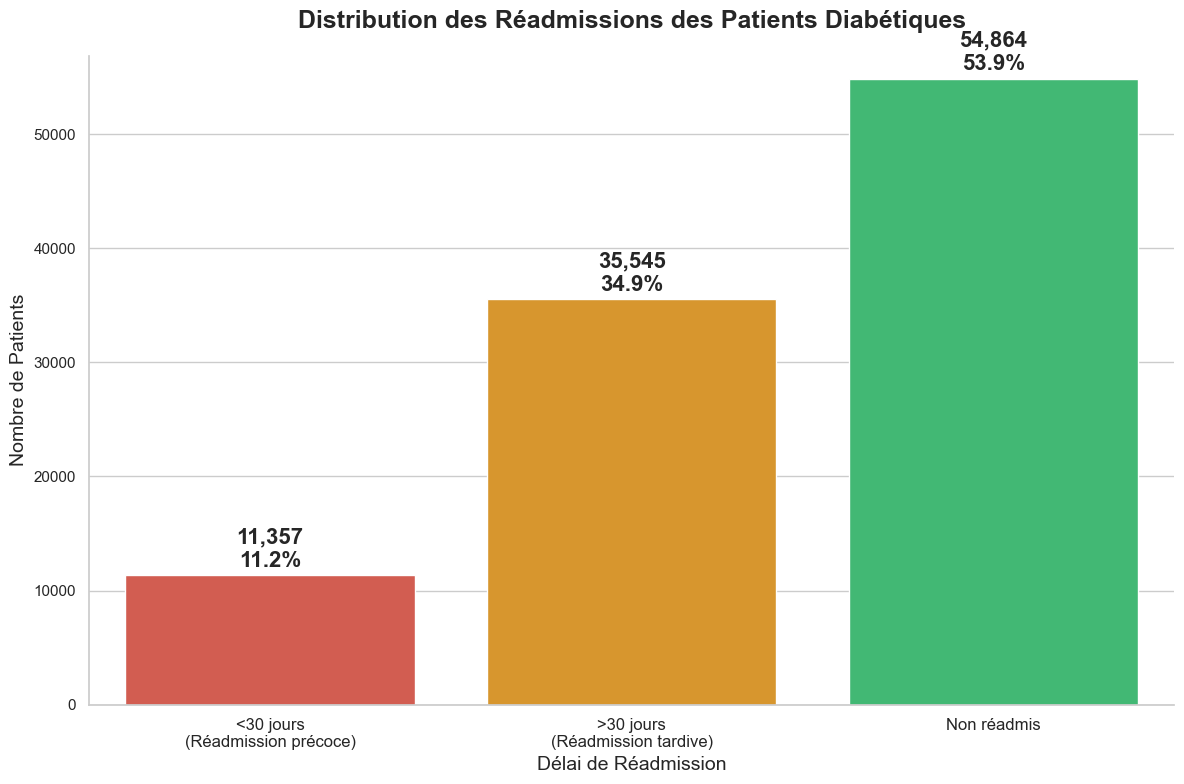

In [540]:


# Définir l'ordre des catégories (du plus critique au moins critique)
order = ['<30', '>30', 'NO']

# Compter les valeurs
counts = df['readmitted'].value_counts().reindex(order)

# Palette de couleurs personnalisée
colors = {'<30': '#E74C3C', '>30': '#F39C12', 'NO': '#2ECC71'}
palette = [colors[cat] for cat in order]

# --- CRÉER LE GRAPHIQUE AVEC UNE TAILLE PLUS GRANDE ---
plt.figure(figsize=(12, 8))  # Augmenté de 10x6 à 12x8

ax = sns.barplot(x=counts.index, y=counts.values, palette=palette)

# --- AJOUTER LES POURCENTAGES AVEC UNE GRANDE POLICE ---
total = len(df)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    percentage = (height / total) * 100
    
    # Texte plus grand et mieux positionné
    ax.text(
        p.get_x() + p.get_width()/2,    # Position X (centre de la barre)
        height + 400,                    # Position Y (au-dessus de la barre)
        f'{int(height):,}\n{percentage:.1f}%',  # Texte : nombre + pourcentage
        ha='center',                     # Centré horizontalement
        va='bottom',                     # Aligné par le bas
        fontsize=16,                     # Police PLUS GRANDE
        fontweight='bold'                # Texte en gras
    )

# --- TITRES ET LABELS ---
plt.title('Distribution des Réadmissions des Patients Diabétiques', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Délai de Réadmission', fontsize=14)
plt.ylabel('Nombre de Patients', fontsize=14)

# Personnaliser les étiquettes de l'axe X
labels = ['<30 jours\n(Réadmission précoce)', 
          '>30 jours\n(Réadmission tardive)', 
          'Non réadmis']
ax.set_xticklabels(labels, fontsize=12)

# --- AJUSTER LES LIMITES ---
plt.ylim(0, max(p.get_height() for p in ax.patches) + 2000)

# Supprimer les bordures inutiles
sns.despine()

plt.tight_layout()
plt.show()

=== TYPES DE VARIABLES ===

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride         

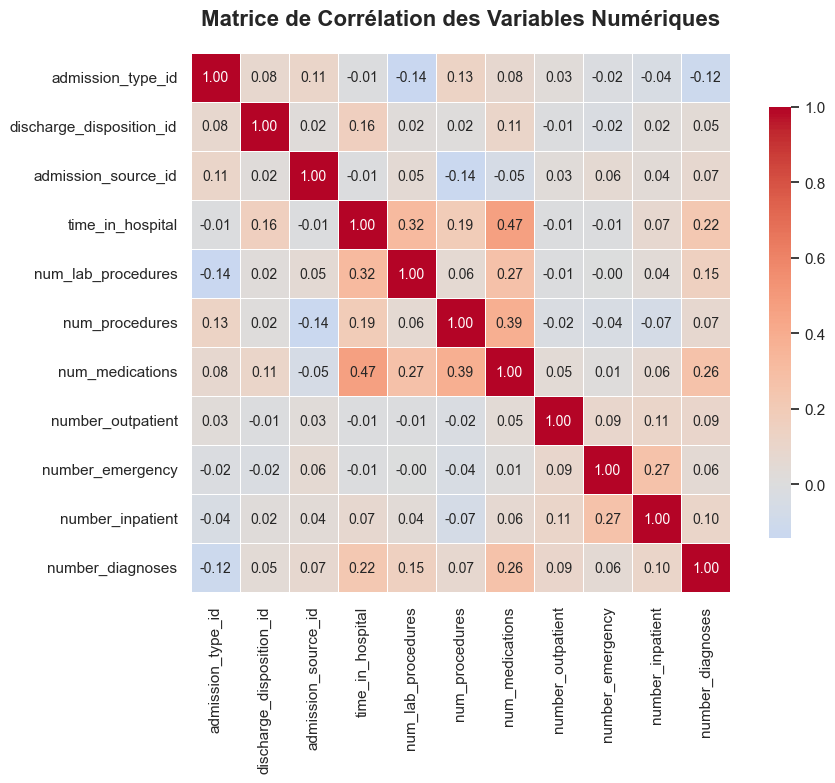

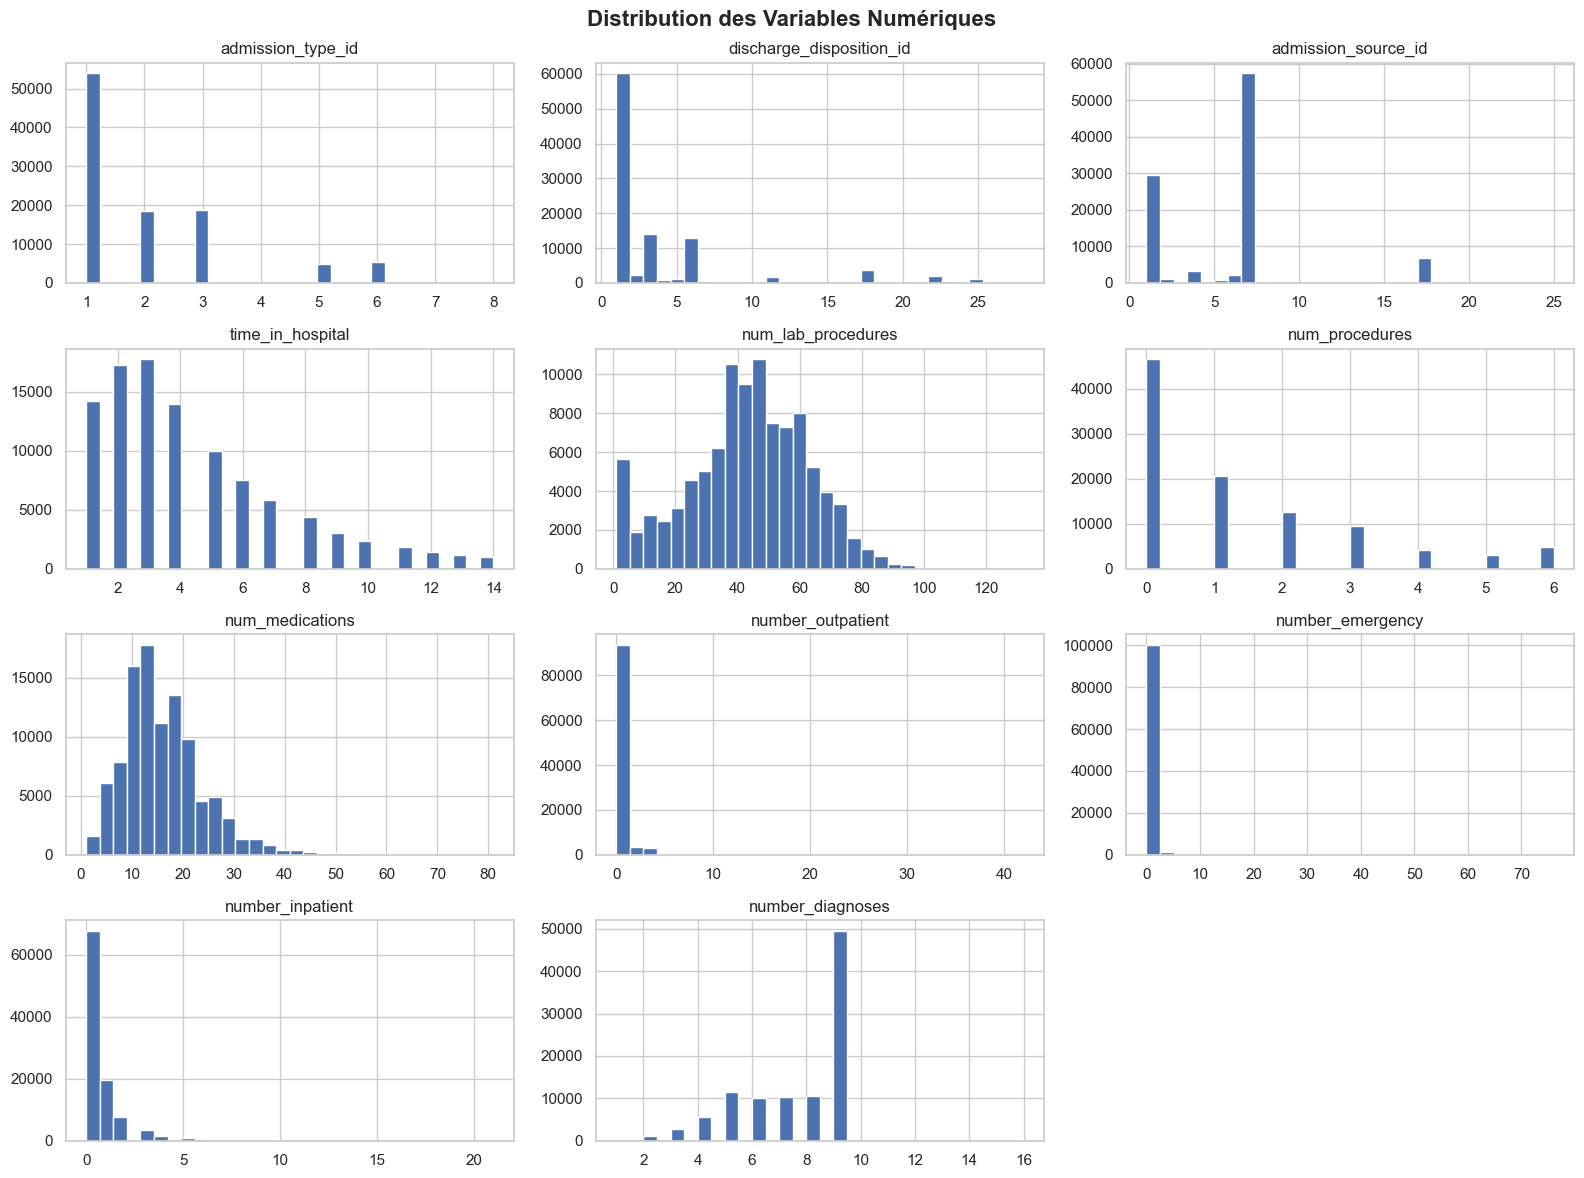

In [541]:
# analyser les variables numériques
print("=== TYPES DE VARIABLES ===\n")
print(df.dtypes)

# Sélectionner les variables numériques (exclure les identifiants)
variables_numeriques = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
exclude_cols = ['encounter_id', 'patient_nbr']
variables_numeriques = [col for col in variables_numeriques if col not in exclude_cols]

print(f"\n📊 Variables numériques analysées : {variables_numeriques}")

# 1. Statistiques descriptives
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)
print("\n=== STATISTIQUES DESCRIPTIVES ===\n")
print(df[variables_numeriques].describe())

# 2. Matrice de corrélation
print("\n=== MATRICE DE CORRÉLATION ===\n")
correlation_matrix = df[variables_numeriques].corr()  
print(correlation_matrix.round(3))

# 3. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            annot=True,           
            cmap='coolwarm',      
            center=0,             
            fmt='.2f',            
            square=True,          
            linewidths=0.5,       
            cbar_kws={"shrink": 0.8},  
            annot_kws={'size': 10})     
plt.title('Matrice de Corrélation des Variables Numériques', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 4. Histogrammes
df[variables_numeriques].hist(figsize=(16, 12), bins=30)
plt.suptitle('Distribution des Variables Numériques', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()




C:\Users\malek\AppData\Local\Temp\ipykernel_20528\3513662069.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


Nombre de variables catégorielles : 37

Liste des variables catégorielles :
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


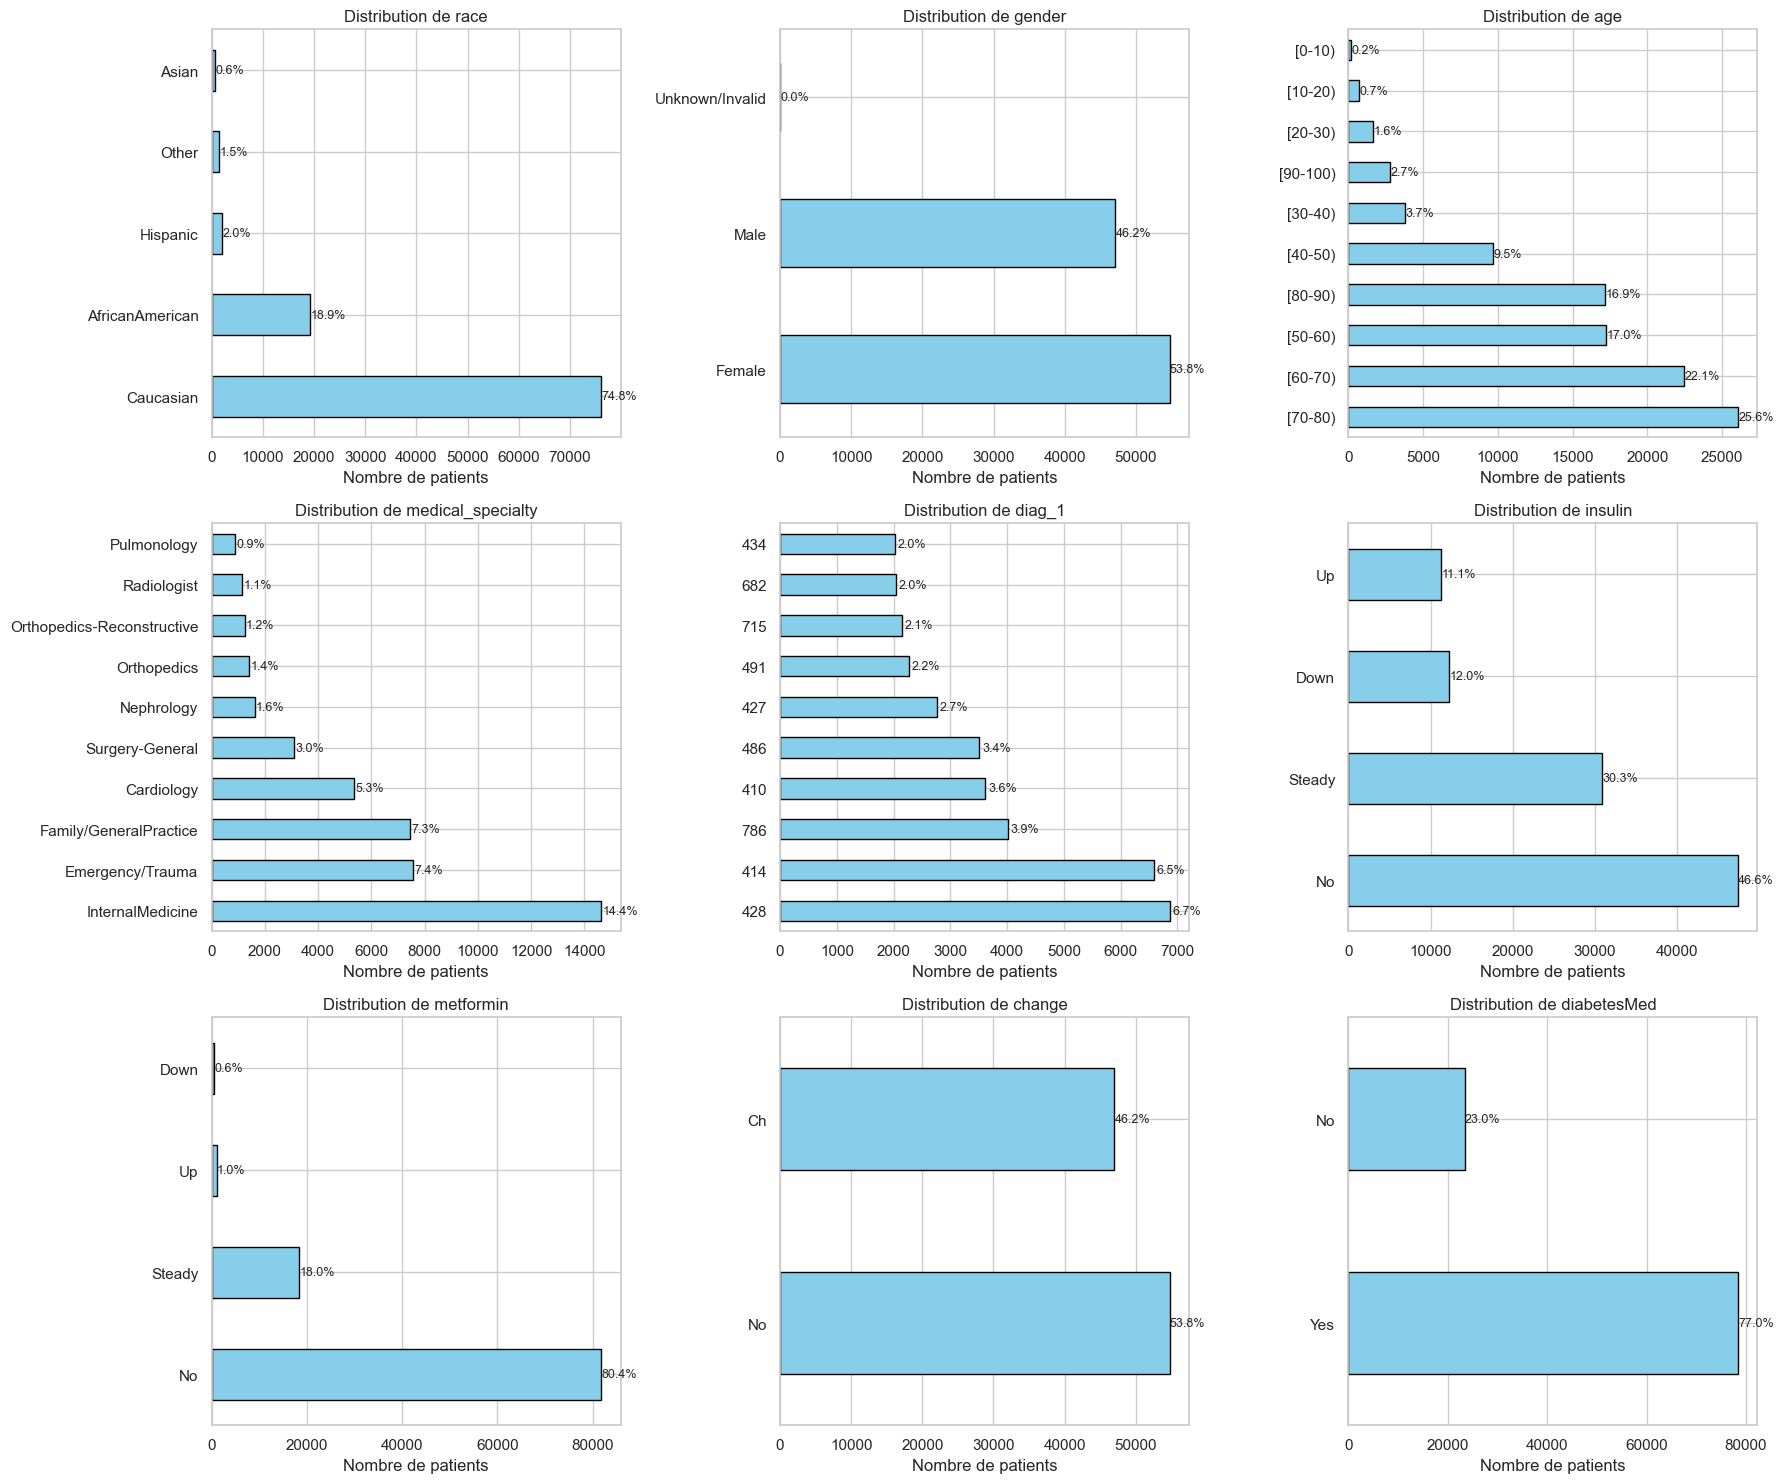

In [542]:
# visualiser les variables categorielles
# Sélectionner les colonnes catégorielles (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Exclure les colonnes qui ne sont pas utiles
exclude_cols = ['encounter_id', 'patient_nbr']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

print(f"Nombre de variables catégorielles : {len(categorical_cols)}")
print("\nListe des variables catégorielles :")
print(categorical_cols)
# Analyser les 10 variables catégorielles les plus intéressantes
top_categorical = ['race', 'gender', 'age', 'medical_specialty', 'diag_1', 
                   'insulin', 'metformin', 'change', 'diabetesMed']

# Filtrer les colonnes qui existent
top_categorical = [col for col in top_categorical if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(top_categorical):
    ax = axes[i]
    data = df[col].value_counts().head(10)  # Top 10 pour lisibilité
    data.plot(kind='barh', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'Distribution de {col}', fontsize=12)
    ax.set_xlabel('Nombre de patients')
    ax.set_ylabel('')
    
    # Ajouter les pourcentages
    total = len(df)
    for j, (label, value) in enumerate(data.items()):
        pct = (value / total) * 100
        ax.text(value + 50, j, f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2238054813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=var,
C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2238054813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=var,
C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2238054813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='readmitted', y=var,
C:\Users\malek\AppData\Local\Temp\ipykernel_20528\2238054813.py:12: FutureWarning: 

Passing `palette` withou

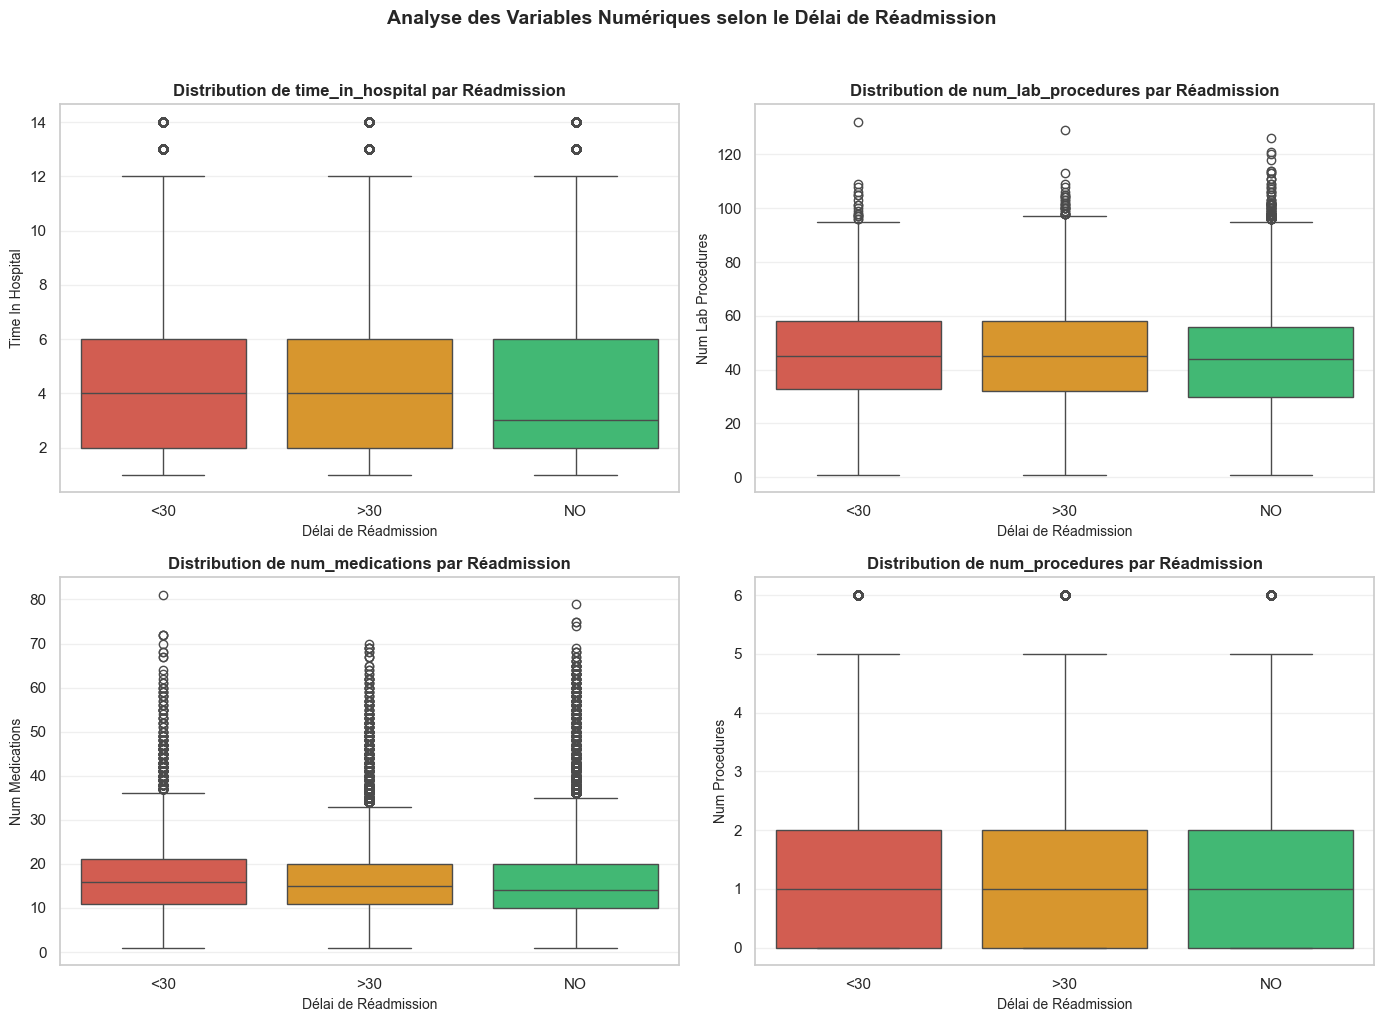

In [543]:


# Sélectionner les variables pertinentes
boxplot_vars = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 'num_procedures']

# Créer une figure avec 4 sous-graphiques
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(boxplot_vars):
    ax = axes[i]
    
    # Boxplot avec ordre logique (<30, >30, NO)
    sns.boxplot(data=df, x='readmitted', y=var, 
                order=['<30', '>30', 'NO'],
                palette=['#E74C3C', '#F39C12', '#2ECC71'],
                ax=ax)
    
    # Titre et labels
    ax.set_title(f'Distribution de {var} par Réadmission', fontsize=12, fontweight='bold')
    ax.set_xlabel('Délai de Réadmission', fontsize=10)
    ax.set_ylabel(var.replace('_', ' ').title(), fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Analyse des Variables Numériques selon le Délai de Réadmission', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

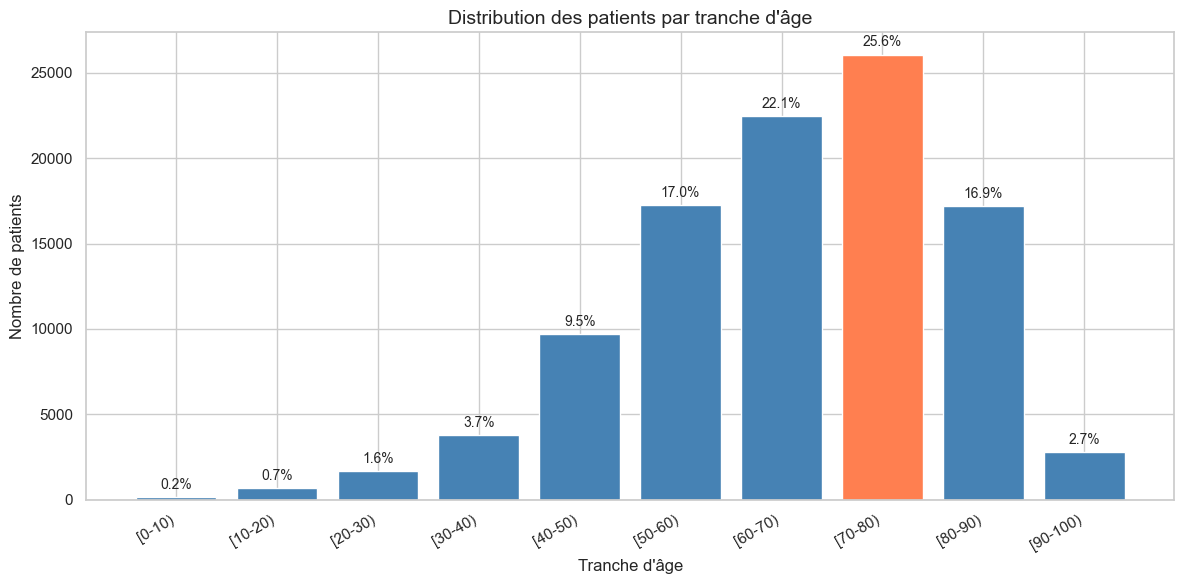

In [544]:
# Impact de l'age sur la réadmission
age_order = ["[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
             "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)"]

age_counts = df["age"].value_counts().reindex(age_order)
pourcentages = (age_counts / len(df) * 100).round(1)

# Couleur différente pour la barre dominante
couleurs = ["steelblue" if age != "[70-80)" else "coral" for age in age_order]

plt.figure(figsize=(12, 6))
bars = plt.bar(age_order, age_counts.values, color=couleurs, edgecolor="white")

for bar, pct in zip(bars, pourcentages):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 300,
             f"{pct}%",
             ha="center", va="bottom", fontsize=10)

plt.title("Distribution des patients par tranche d'âge", fontsize=14)
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre de patients")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

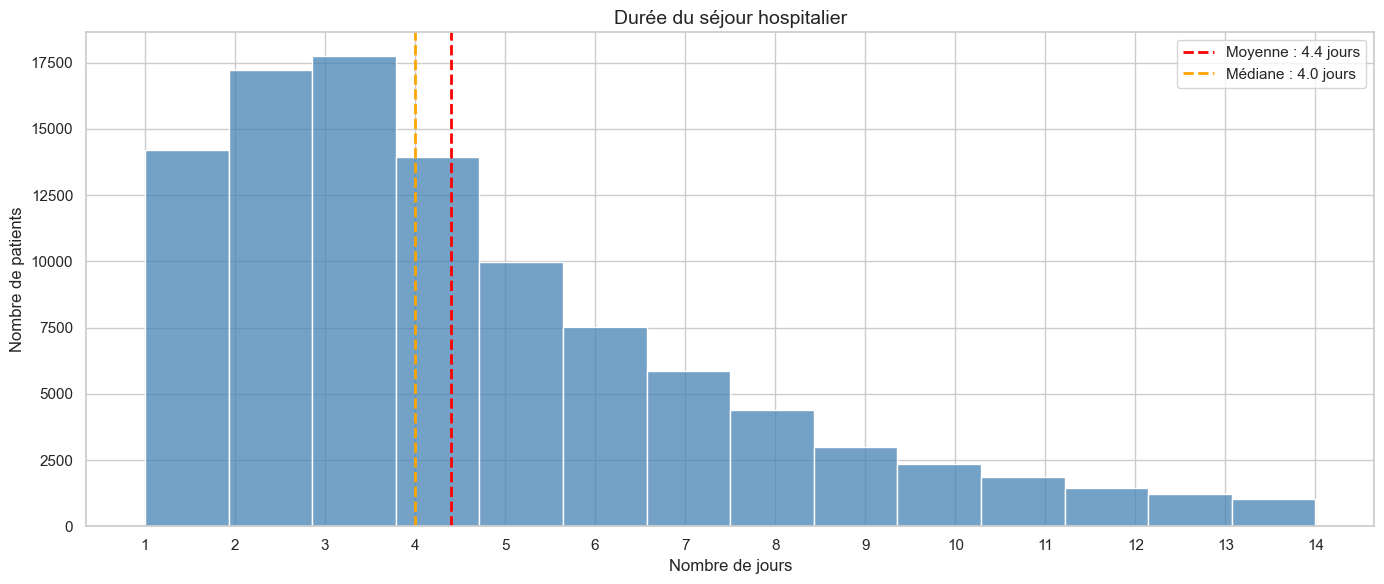

Moyenne  : 4.4 jours
Médiane  : 4.0 jours
Maximum  : 14 jours
Minimum  : 1 jours


In [545]:
# Durée de séjour à l'hopital

plt.figure(figsize=(14, 6))

ax = sns.histplot(df["time_in_hospital"], bins=14,
                  color="steelblue", edgecolor="white")

moyenne = df["time_in_hospital"].mean()
mediane = df["time_in_hospital"].median()

plt.axvline(moyenne, color="red", linestyle="--",
            linewidth=2, label=f"Moyenne : {moyenne:.1f} jours")
plt.axvline(mediane, color="orange", linestyle="--",
            linewidth=2, label=f"Médiane : {mediane:.1f} jours")

plt.title("Durée du séjour hospitalier", fontsize=14)
plt.xlabel("Nombre de jours")
plt.ylabel("Nombre de patients")
plt.xticks(range(1, 15))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Moyenne  : {moyenne:.1f} jours")
print(f"Médiane  : {mediane:.1f} jours")
print(f"Maximum  : {df['time_in_hospital'].max()} jours")
print(f"Minimum  : {df['time_in_hospital'].min()} jours")

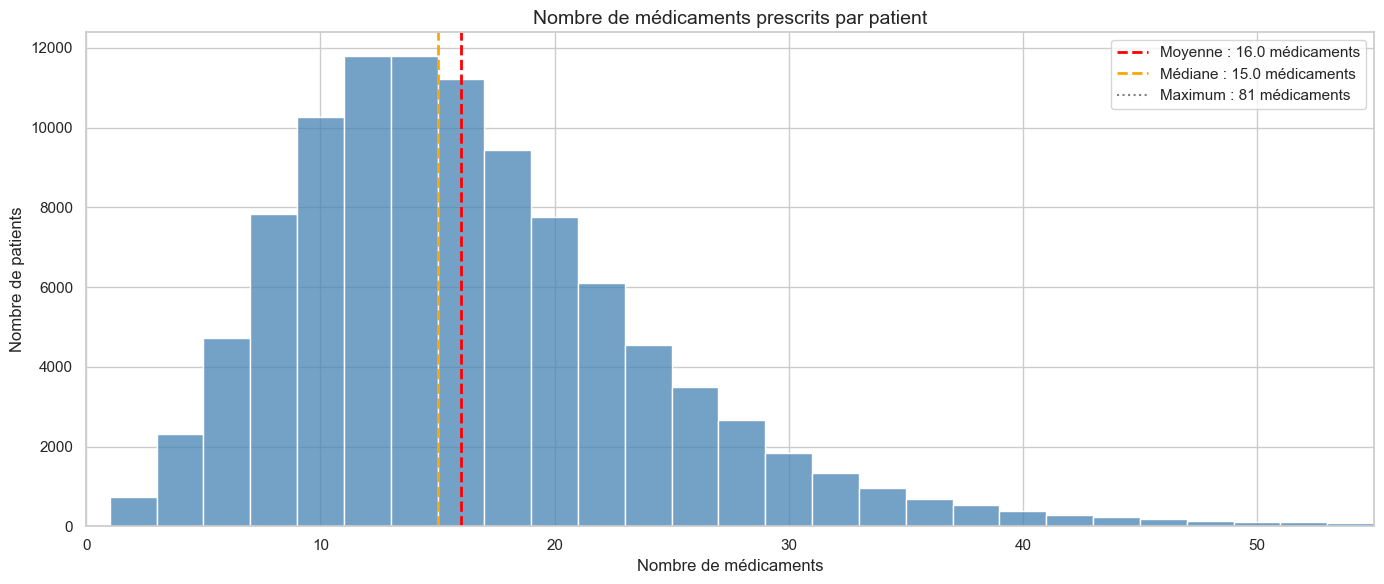

Moyenne  : 16.0 médicaments
Médiane  : 15.0 médicaments
Maximum  : 81 médicaments
Minimum  : 1 médicaments


In [546]:
# Impact du nombre de médicaments sur la réadmission 
plt.figure(figsize=(14, 6))

sns.histplot(df["num_medications"], bins=40,
             color="steelblue", edgecolor="white")

moyenne = df["num_medications"].mean()
mediane = df["num_medications"].median()

plt.axvline(moyenne, color="red", linestyle="--",
            linewidth=2, label=f"Moyenne : {moyenne:.1f} médicaments")
plt.axvline(mediane, color="orange", linestyle="--",
            linewidth=2, label=f"Médiane : {mediane:.1f} médicaments")

# Annoter les valeurs extrêmes
plt.axvline(df["num_medications"].max(), color="gray",
            linestyle=":", linewidth=1.5,
            label=f"Maximum : {df['num_medications'].max()} médicaments")

plt.title("Nombre de médicaments prescrits par patient", fontsize=14)
plt.xlabel("Nombre de médicaments")
plt.ylabel("Nombre de patients")
plt.xlim(0, 55)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Moyenne  : {moyenne:.1f} médicaments")
print(f"Médiane  : {mediane:.1f} médicaments")
print(f"Maximum  : {df['num_medications'].max()} médicaments")
print(f"Minimum  : {df['num_medications'].min()} médicaments")

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64
readmitted_binary
0    88.8
1    11.2
Name: proportion, dtype: float64


C:\Users\malek\AppData\Local\Temp\ipykernel_20528\4024267257.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="readmitted_binary", data=df, palette=['#2ECC71', '#E74C3C'])
c:\Users\malek\OneDrive\Desktop\projet_tej\.venv311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


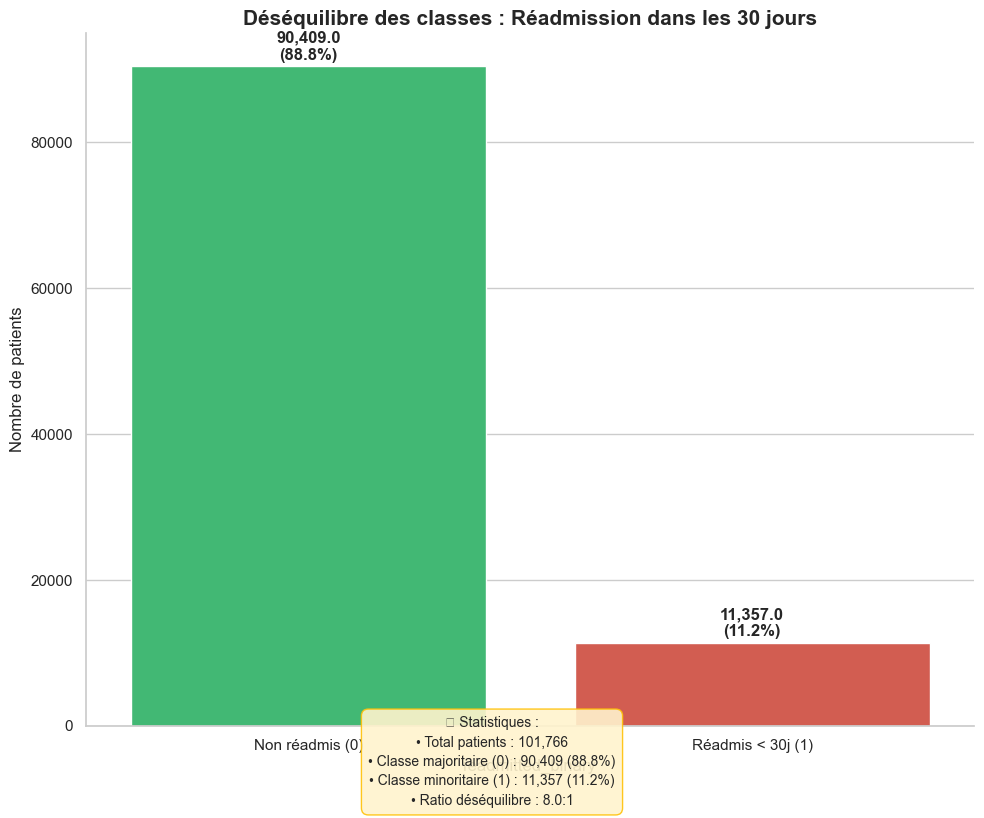

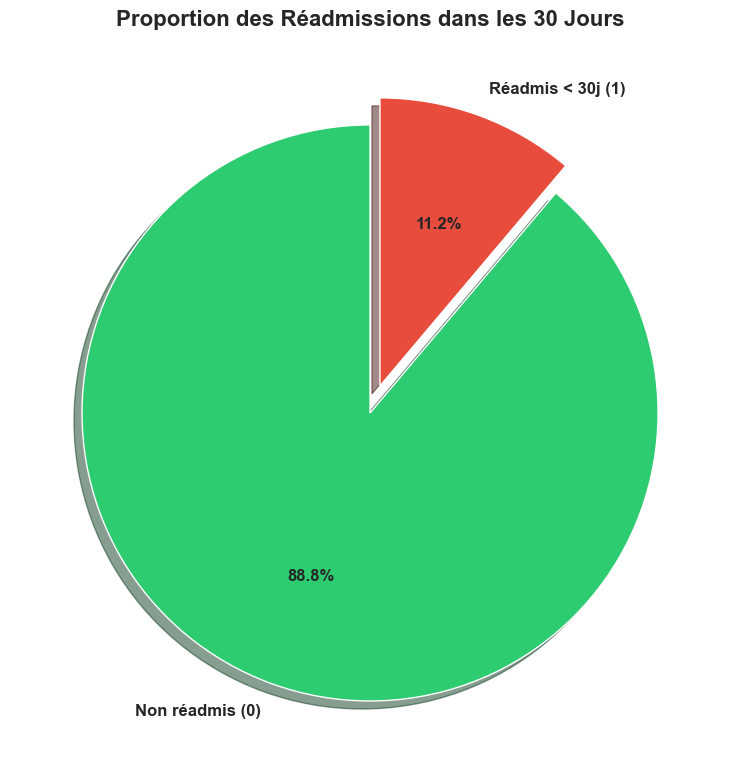

In [ ]:
# ============================================
# ANALYSE DU DÉSÉQUILIBRE DES CLASSES
# ============================================
# On crée la version binaire de la cible pour visualiser le déséquilibre
# "<30" = réadmis en moins de 30 jours = 1
# "NO" et ">30" = non réadmis dans les 30 jours = 0
df["readmitted_binary"] = (df["readmitted"] == "<30").astype(int)

print(df["readmitted_binary"].value_counts())
print(df["readmitted_binary"].value_counts(normalize=True).round(3) * 100)

fig, ax = plt.subplots(figsize=(10, 8))  # LÉGÈREMENT PLUS GRAND
sns.countplot(x="readmitted_binary", data=df, palette=['#2ECC71', '#E74C3C'])

# Ajouter les valeurs sur les barres
total = len(df)
for i, p in enumerate(ax.patches):
    count = p.get_height()
    percentage = (count / total) * 100
    ax.text(p.get_x() + p.get_width()/2, count + 500,
            f'{count:,}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Déséquilibre des classes : Réadmission dans les 30 jours", fontsize=15, fontweight='bold')
plt.xticks([0, 1], ["Non réadmis (0)", "Réadmis < 30j (1)"])
plt.ylabel("Nombre de patients", fontsize=12)

# --- UNE SEULE MODIFICATION : AJOUTER DE L'ESPACE EN BAS ---
plt.subplots_adjust(bottom=0.25)  # <-- Ajoutez cette ligne

# Texte en bas (inchangé)
stats_text = (
    f"📊 Statistiques :\n"
    f"• Total patients : {total:,}\n"
    f"• Classe majoritaire (0) : {sum(df['readmitted_binary'] == 0):,} ({((sum(df['readmitted_binary'] == 0) / total) * 100):.1f}%)\n"
    f"• Classe minoritaire (1) : {sum(df['readmitted_binary'] == 1):,} ({((sum(df['readmitted_binary'] == 1) / total) * 100):.1f}%)\n"
    f"• Ratio déséquilibre : {sum(df['readmitted_binary'] == 0) / sum(df['readmitted_binary'] == 1):.1f}:1"
)

plt.figtext(0.5, -0.02, stats_text, ha='center', va='bottom', 
            fontsize=10, linespacing=1.5,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3CD', edgecolor='#FFC107', alpha=0.9))

sns.despine()
plt.tight_layout()
plt.show()

# --- 3. Graphique en camembert (optionnel) ---
fig, ax = plt.subplots(figsize=(8, 8))

df["readmitted_binary"].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Non réadmis (0)', 'Réadmis < 30j (1)'],
    colors=['#2ECC71', '#E74C3C'],
    explode=(0, 0.1),  # Faire ressortir la classe minoritaire
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Proportion des Réadmissions dans les 30 Jours', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('')  # Supprimer le label par défaut

plt.tight_layout()
plt.show()